In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress


Calibration Equation: L_corr = 1.0287 * L_obs + -146.96

--- IODINE PHYSICAL CONSTANTS ---
Average Wavenumber Spacing: 103.29 cm^-1
Approximate Electronic Energy Gap: 1.9892 eV
Bond Dissociation Energy (D0): 0.2432 eV
Excited State Force Constant (f): 39.92 N/m

CSVs and Graph generated successfully in your directory.


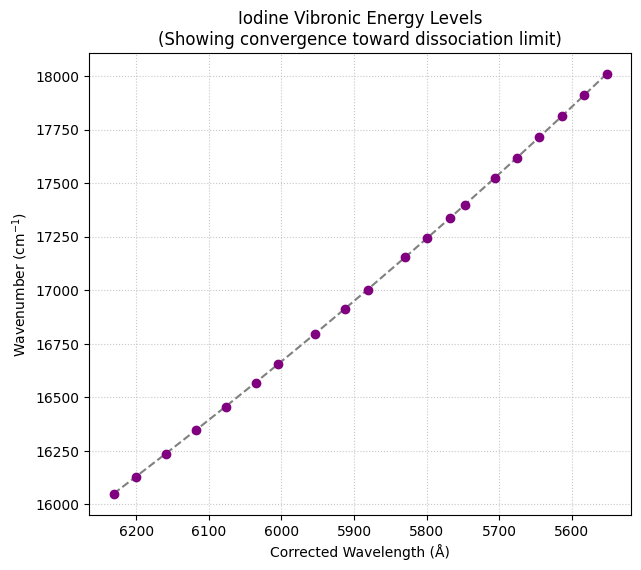

In [13]:

# ==========================================
# 1. RAW DATA INPUTS
# ==========================================
calib_L_obs = np.array([6870, 6200, 6150, 6110, 5940, 5770, 5460, 4950, 4910, 4370, 4090, 4060])
calib_L_giv = np.array([6910, 6230, 6200, 6150, 5960, 5790, 5460, 4940, 4890, 4350, 4070, 4030])

cu_L_obs = np.array([6670, 6540, 6360, 5880, 5780, 5690, 5300, 5220, 5150, 5100, 4810, 4730, 4710, 4650, 4590, 4540, 4520, 4490, 4420, 4390, 4290, 4260, 4190, 4080])
brass_L_obs = np.array([6370, 6890, 5770, 5690, 5300, 5220, 5150, 5100, 4810, 4730, 4680, 4650, 4590, 4540, 4510, 4490, 4400, 4270, 4060])
iodine_L_obs = np.array([6200, 6170, 6130, 6090, 6050, 6010, 5980, 5930, 5890, 5860, 5810, 5780, 5750, 5730, 5690, 5660, 5630, 5600, 5570, 5540])

# Prominent Visible Standard Lines (NIST approximation in Angstroms)
cu_standard = np.array([4062, 4275, 4651, 5105, 5153, 5218, 5700, 5782])
zn_standard = np.array([4080, 4680, 4722, 4810, 6362]) # Zinc lines for Brass comparison
brass_standard = np.sort(np.concatenate((cu_standard, zn_standard)))

# ==========================================
# 2. CALIBRATION
# ==========================================
slope, intercept, r_value, p_value, std_err = linregress(calib_L_obs, calib_L_giv)
print(f"Calibration Equation: L_corr = {slope:.4f} * L_obs + {intercept:.2f}\n")

# ==========================================
# 3. HELPER FUNCTION: MATCH LITERATURE VALUES
# ==========================================
def match_literature(corrected_array, standard_array, tolerance=30):
    lit_matches = []
    errors = []
    for val in corrected_array:
        # Find closest standard line
        diffs = np.abs(standard_array - val)
        min_idx = np.argmin(diffs)
        if diffs[min_idx] <= tolerance:
            matched_val = standard_array[min_idx]
            err = (np.abs(val - matched_val) / matched_val) * 100
            lit_matches.append(matched_val)
            errors.append(round(err, 2))
        else:
            lit_matches.append(None)
            errors.append(None)
    return lit_matches, errors

# ==========================================
# 4. PROCESS METALS (COPPER & BRASS)
# ==========================================
cu_L_corr = slope * cu_L_obs + intercept
cu_lit, cu_err = match_literature(cu_L_corr, cu_standard)

df_cu = pd.DataFrame({
    'Sl. No.': np.arange(1, len(cu_L_obs) + 1),
    'Observed (A)': cu_L_obs,
    'Corrected (A)': np.round(cu_L_corr, 1),
    'Lit. Match (A)': cu_lit,
    '% Error': cu_err
})
df_cu.to_csv("Report_Copper_Emission.csv", index=False)

brass_L_corr = slope * brass_L_obs + intercept
brass_lit, brass_err = match_literature(brass_L_corr, brass_standard)

df_brass = pd.DataFrame({
    'Sl. No.': np.arange(1, len(brass_L_obs) + 1),
    'Observed (A)': brass_L_obs,
    'Corrected (A)': np.round(brass_L_corr, 1),
    'Lit. Match (A)': brass_lit,
    '% Error': brass_err
})
df_brass.to_csv("Report_Brass_Emission.csv", index=False)

# ==========================================
# 5. PROCESS IODINE ABSORPTION
# ==========================================
iodine_L_corr = slope * iodine_L_obs + intercept
wavenumbers = 10**8 / iodine_L_corr
diff_wavenumbers = np.abs(np.diff(wavenumbers))
diff_wavenumbers = np.insert(diff_wavenumbers, 0, 0)

df_iodine = pd.DataFrame({
    'Sl. No.': np.arange(1, len(iodine_L_obs) + 1),
    'Observed (A)': iodine_L_obs,
    'Corrected (A)': np.round(iodine_L_corr, 1),
    'Wave number (cm^-1)': np.round(wavenumbers, 1),
    'Delta Wave number (cm^-1)': np.round(diff_wavenumbers, 1)
})
df_iodine.to_csv("Report_Iodine_Absorption.csv", index=False)

# Calculations
v_avg = np.mean(diff_wavenumbers[1:])
highest_wl = np.max(iodine_L_corr)
lowest_wn = 10**8 / highest_wl
energy_gap_eV = lowest_wn / 8068

highest_wn = np.max(wavenumbers)
D0_cm = highest_wn - lowest_wn
D0_eV = D0_cm / 8068

mu_kg = 1.053e-25
c_cm_s = 3e10
f = 4 * (np.pi**2) * mu_kg * (c_cm_s * v_avg)**2

print("--- IODINE PHYSICAL CONSTANTS ---")
print(f"Average Wavenumber Spacing: {v_avg:.2f} cm^-1")
print(f"Approximate Electronic Energy Gap: {energy_gap_eV:.4f} eV")
print(f"Bond Dissociation Energy (D0): {D0_eV:.4f} eV")
print(f"Excited State Force Constant (f): {f:.2f} N/m")

# Plotting the Anharmonic Convergence
plt.figure(figsize=(7, 6))
plt.scatter(iodine_L_corr, wavenumbers, color='purple', zorder=5)
plt.plot(iodine_L_corr, wavenumbers, linestyle='--', color='gray')
plt.title("Iodine Vibronic Energy Levels\n(Showing convergence toward dissociation limit)")
plt.xlabel("Corrected Wavelength (Å)")
plt.ylabel("Wavenumber (cm$^{-1}$)")
plt.gca().invert_xaxis() # Invert x-axis so higher energy is on the right
plt.grid(True, linestyle=':', alpha=0.7)
plt.savefig("Report_Iodine_Convergence.png")
print("\nCSVs and Graph generated successfully in your directory.")

<>:31: SyntaxWarning: invalid escape sequence '\o'
<>:31: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_5287/2983808721.py:31: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel("Wavenumber $\overline{\\nu}$ (cm$^{-1}$)")


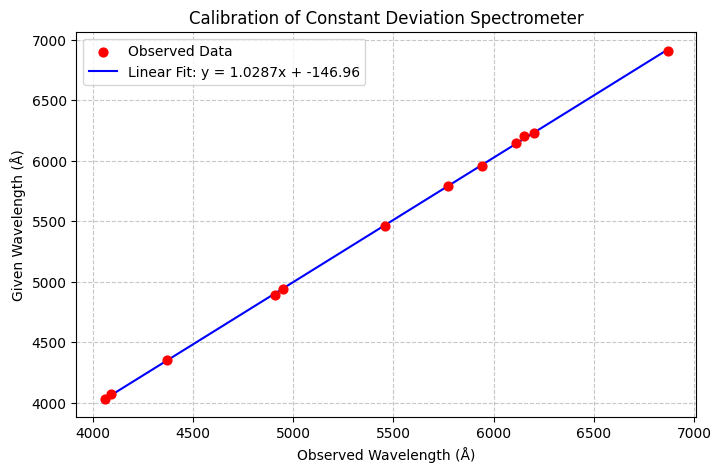

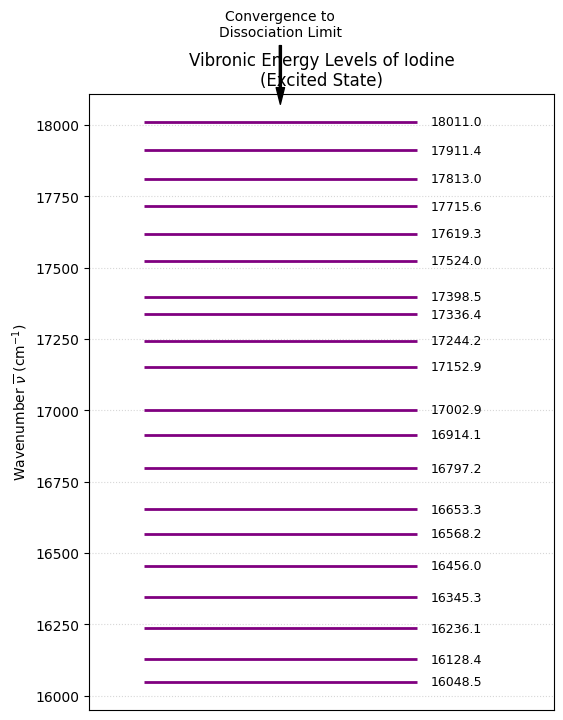

In [4]:
# ==========================================
# 6. GENERATE GRAPHS
# ==========================================

# --- PLOT 1: Calibration Graph ---
plt.figure(figsize=(8, 5))
# Plot the raw observed vs given points
plt.scatter(calib_L_obs, calib_L_giv, color='red', s=40, label='Observed Data', zorder=5)
# Plot the calculated line of best fit
plt.plot(calib_L_obs, slope * calib_L_obs + intercept, color='blue', linestyle='-', 
         label=f'Linear Fit: y = {slope:.4f}x + {intercept:.2f}', zorder=4)

plt.title("Calibration of Constant Deviation Spectrometer")
plt.xlabel("Observed Wavelength (Å)")
plt.ylabel("Given Wavelength (Å)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig("Report_Calibration_Graph.png", dpi=300, bbox_inches='tight')
plt.show()

# --- PLOT 2: Iodine Vibronic Energy Level Diagram ---
plt.figure(figsize=(6, 8))
# Plot a horizontal line for each calculated wavenumber
for wn in wavenumbers:
    plt.hlines(wn, xmin=0, xmax=1, colors='purple', linewidth=2)
    # Label each line with its exact wavenumber value
    plt.text(1.05, wn, f"{wn:.1f}", va='center', fontsize=9)
    
plt.xlim(-0.2, 1.5)
plt.title("Vibronic Energy Levels of Iodine\n(Excited State)")
plt.ylabel("Wavenumber $\overline{\\nu}$ (cm$^{-1}$)")
# Remove x-axis ticks since the horizontal axis is just for visual width
plt.xticks([]) 
plt.grid(axis='y', linestyle=':', alpha=0.5)

# Add an arrow and text to indicate convergence toward the dissociation limit
plt.annotate('Convergence to\nDissociation Limit', xy=(0.5, np.max(wavenumbers) + 50), 
             xytext=(0.5, np.max(wavenumbers) + 300),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=6),
             ha='center')

plt.savefig("Report_Iodine_Energy_Levels.png", dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# Error analysis for Iodine

# Instrument Least Count
delta_L_obs = 10.0 # Angstroms

# 2. Calibration with Covariance Matrix
p, V = np.polyfit(calib_L_obs, calib_L_giv, 1, cov=True)
m, c = p
var_m, var_c, cov_mc = V[0,0], V[1,1], V[0,1]

# 3. Wavelength Error Propagation
iodine_L_corr = m * iodine_L_obs + c
# Applying the rigorous covariance error formula
delta_L_corr = np.sqrt((m * delta_L_obs)**2 + (iodine_L_obs**2 * var_m) + var_c + (2 * iodine_L_obs * cov_mc))

# 4. Wavenumber Error Propagation
wavenumbers = 10**8 / iodine_L_corr
delta_nu = (10**8 / iodine_L_corr**2) * delta_L_corr

# 5. Vibronic Spacing Error
diff_wavenumbers = np.abs(np.diff(wavenumbers))
delta_diff_nu = np.sqrt(delta_nu[:-1]**2 + delta_nu[1:]**2)

v_avg = np.mean(diff_wavenumbers)
N = len(diff_wavenumbers)
delta_v_avg = (1 / N) * np.sqrt(np.sum(delta_diff_nu**2))

# 6. Force Constant Error Propagation
mu_kg = 1.053e-25
c_cm_s = 3e10
f = 4 * (np.pi**2) * mu_kg * (c_cm_s * v_avg)**2
delta_f = 2 * f * (delta_v_avg / v_avg)

# 7. Dissociation Energy Error Propagation
lowest_wn = wavenumbers[0]  # lowest energy / highest wavelength
highest_wn = wavenumbers[-1] # highest energy / lowest wavelength

D0_cm = highest_wn - lowest_wn
delta_D0_cm = np.sqrt(delta_nu[0]**2 + delta_nu[-1]**2)

D0_eV = D0_cm / 8068
delta_D0_eV = delta_D0_cm / 8068

# Output Results with Error Bars
print("==================================================")
print("FINAL RESULTS WITH ERROR PROPAGATION")
print("==================================================\n")
print(f"Calibration Slope (m): {m:.4f} ± {np.sqrt(var_m):.4f}")
print(f"Calibration Intercept (c): {c:.2f} ± {np.sqrt(var_c):.2f}\n")

print(f"Average Wavenumber Spacing (Δv_avg): {v_avg:.2f} ± {delta_v_avg:.2f} cm^-1")
print(f"Excited State Force Constant (f): {f:.2f} ± {delta_f:.2f} N/m")
print(f"Bond Dissociation Energy (D0): {D0_eV:.4f} ± {delta_D0_eV:.4f} eV")
print("==================================================")

FINAL RESULTS WITH ERROR PROPAGATION

Calibration Slope (m): 1.0287 ± 0.0034
Calibration Intercept (c): -146.96 ± 18.67

Average Wavenumber Spacing (Δv_avg): 103.29 ± 10.24 cm^-1
Excited State Force Constant (f): 39.92 ± 7.92 N/m
Bond Dissociation Energy (D0): 0.2432 ± 0.0056 eV


In [11]:
#Error in electronic energy gap
delta_E_gap= delta_nu/8068
print(f"Electronic Energy Gap: {lowest_wn/8068:.4f} ± {delta_E_gap[0]:.4f} eV")

Electronic Energy Gap: 1.9892 ± 0.0035 eV
